# Session 9 - Probability Distributions (Continuous)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

## Task 1 — 1000 Random Normal Values (mean=500, sd=100)

Sample mean: 501.93
Sample std dev: 97.87


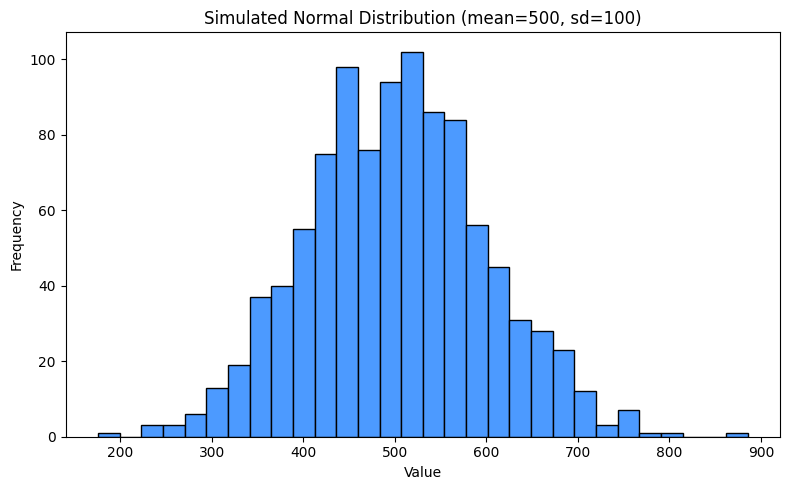

In [2]:
sample_data = np.random.normal(loc=500, scale=100, size=1000)

print('Sample mean:', round(sample_data.mean(), 2))
print('Sample std dev:', round(sample_data.std(), 2))

plt.figure(figsize=(8, 5))
plt.hist(sample_data, bins=30, color='#4c9aff', edgecolor='black')
plt.title('Simulated Normal Distribution (mean=500, sd=100)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Task 2 — Z-score for 9500 Daily Steps

$$Z = \dfrac{X - \mu}{\sigma}$$

In [3]:
X = 9500
mu = 8000
sigma = 1200

z_score = (X - mu) / sigma
print('Z-score:', z_score)

Z-score: 1.25


**Interpretation:** A Z-score of **1.25** means that day's step count was 1.25 standard deviations above the mean — a noticeably active day, but not an extreme outlier (Z-scores beyond ±2 or ±3 are where 'extreme' usually starts).

## Task 3 — Standard Normal Curve with Shaded ±1 SD Region

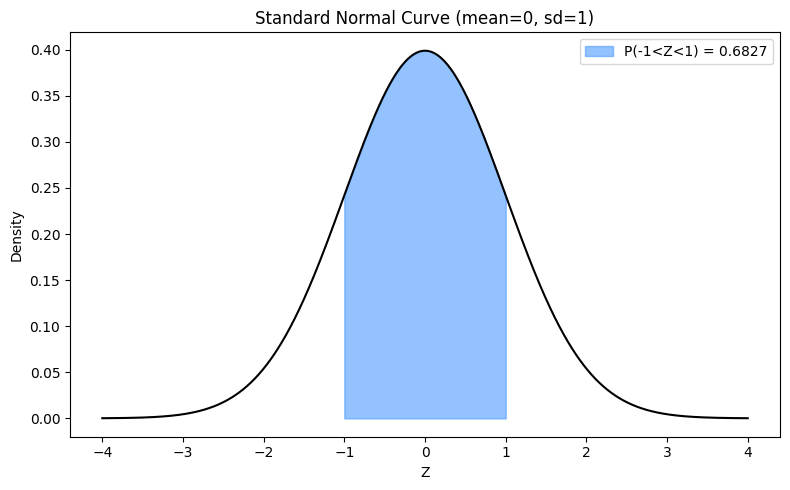

Area between Z=-1 and Z=1: 0.6826894921370859


In [4]:
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

x_shade = np.linspace(-1, 1, 500)
y_shade = norm.pdf(x_shade, 0, 1)

area_within_1sd = norm.cdf(1) - norm.cdf(-1)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='black')
plt.fill_between(x_shade, y_shade, color='#4c9aff', alpha=0.6, label=f'P(-1<Z<1) = {area_within_1sd:.4f}')
plt.title('Standard Normal Curve (mean=0, sd=1)')
plt.xlabel('Z')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

print('Area between Z=-1 and Z=1:', area_within_1sd)

## Task 4 — P(Delivery Time < 25 min), Normal(mean=30, sd=5)

In [5]:
delivery_mean = 30
delivery_sd = 5

p_less_than_25 = norm.cdf(25, loc=delivery_mean, scale=delivery_sd)
print('P(delivery time < 25 min) =', p_less_than_25)

P(delivery time < 25 min) = 0.15865525393145707


**Interpretation:** About **15.9%** of deliveries are expected to finish in under 25 minutes — 25 minutes is exactly 1 standard deviation below the mean (Z = -1), so this matches the standard normal table value for P(Z < -1).

## Task 5 — Why the Normal Distribution Matters for App Data

**Prompt used:** "Explain in your own words why the normal distribution is important for analyzing real-world app data like sales, delivery times, or user ratings."

**AI's answer:** Many real-world metrics that apps track — like daily sales totals, delivery times, or average user ratings — tend to cluster around a typical value with fewer extreme cases the further you move from it, which is exactly the shape the normal distribution describes. That matters practically: once analysts confirm a metric is roughly normal, they can use just two numbers — the mean and standard deviation — to estimate what counts as typical versus unusual, flag anomalies (like a delivery time far outside the expected range), set realistic performance targets, and run standard statistical tests that assume normality. It turns a messy spread of thousands of data points into something summarizable and predictable, which is a big part of why it shows up so often in analytics work.